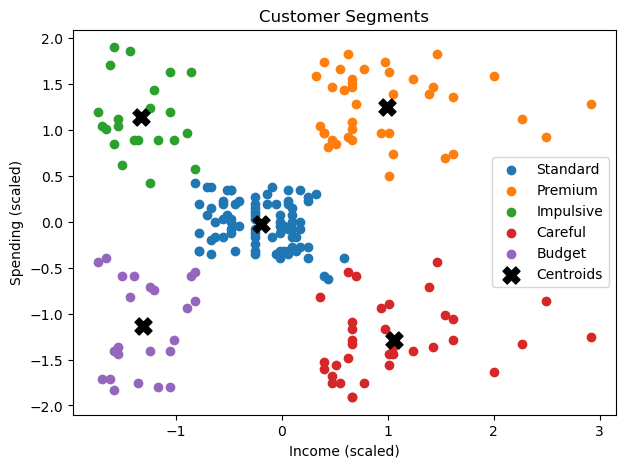

Cluster Centers (original scale):
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster    Segment  
0        4     Budget  
1        2  Impulsive  
2        4     Budget  
3        2  Impulsive  
4        4     Budget  


In [12]:
import os
os.environ["OMP_NUM_THREADS"] = "1"   # Fix MKL warning

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train k-Means
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# Get centroids in original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Assign simple meanings
def label(income, score):
    if income > 70 and score > 60:
        return "Premium"
    elif income > 70 and score < 40:
        return "Careful"
    elif income < 40 and score > 60:
        return "Impulsive"
    elif income < 40 and score < 40:
        return "Budget"
    else:
        return "Standard"

cluster_names = {i: label(c[0], c[1]) for i, c in enumerate(centroids)}

# Plot
plt.figure(figsize=(7,5))

for i in range(5):
    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        label=cluster_names[i]
    )

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='black', s=150, marker='X', label='Centroids')

plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")
plt.title("Customer Segments")
plt.legend()
plt.show()

print("Cluster Centers (original scale):\n", centroids)
df["Segment"] = df["Cluster"].map(cluster_names)

print(df.head())